**Importing Libraries**

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

**Importing and Loading Dataset**

In [36]:
df = pd.read_csv('train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**---------Exploratory Data Analysis-------------**

**DataSet Information**

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


**DataSet Shape**

In [38]:
df.shape

(614, 13)

**Check Missing Values**

In [39]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [40]:
df.dtypes.value_counts()

object     8
float64    4
int64      1
Name: count, dtype: int64

<Axes: xlabel='Loan_Status', ylabel='count'>

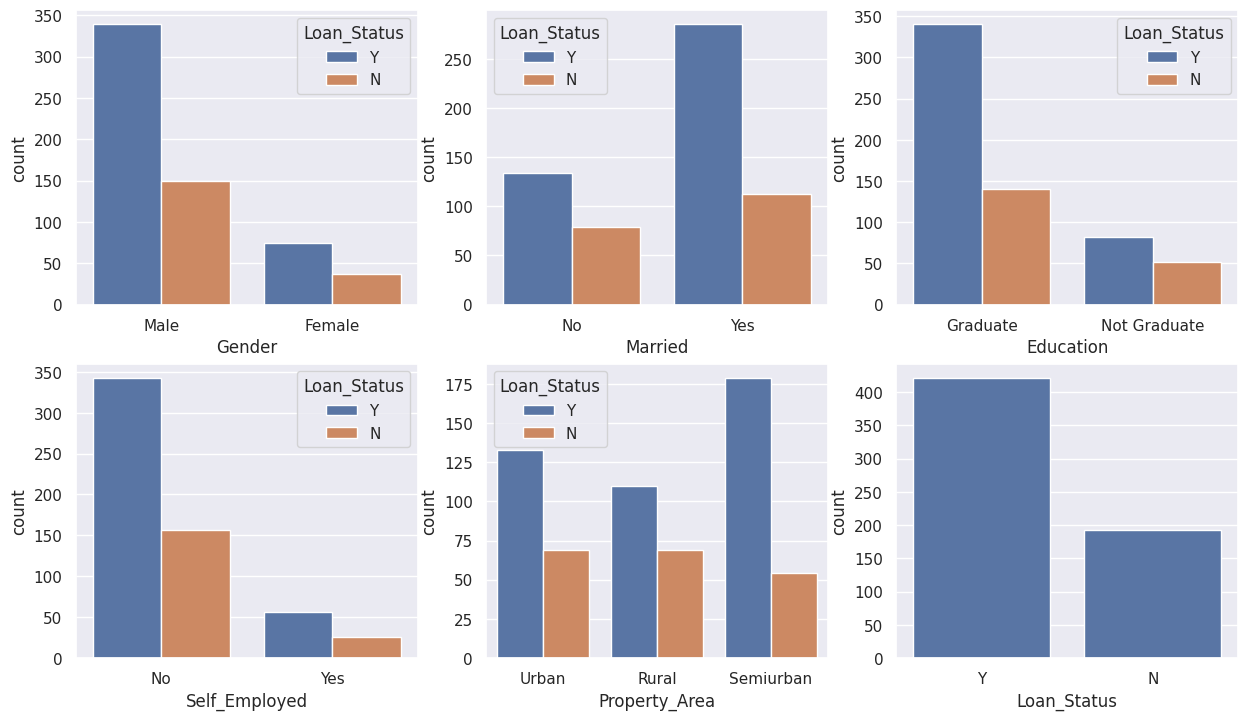

In [41]:
plt.figure(figsize=(15,13))
sns.set(font_scale = 1)
plt.subplot(331)
sns.countplot(x=df['Gender'], hue=df['Loan_Status'])

plt.subplot(332)
sns.countplot(x=df['Married'], hue=df['Loan_Status'])

plt.subplot(333)
sns.countplot(x=df['Education'], hue=df['Loan_Status'])

plt.subplot(334)
sns.countplot(x=df['Self_Employed'], hue=df['Loan_Status'])

plt.subplot(335)
sns.countplot(x=df['Property_Area'], hue=df['Loan_Status'])

plt.subplot(336)
sns.countplot(x=df['Loan_Status'])

<function matplotlib.pyplot.show(close=None, block=None)>

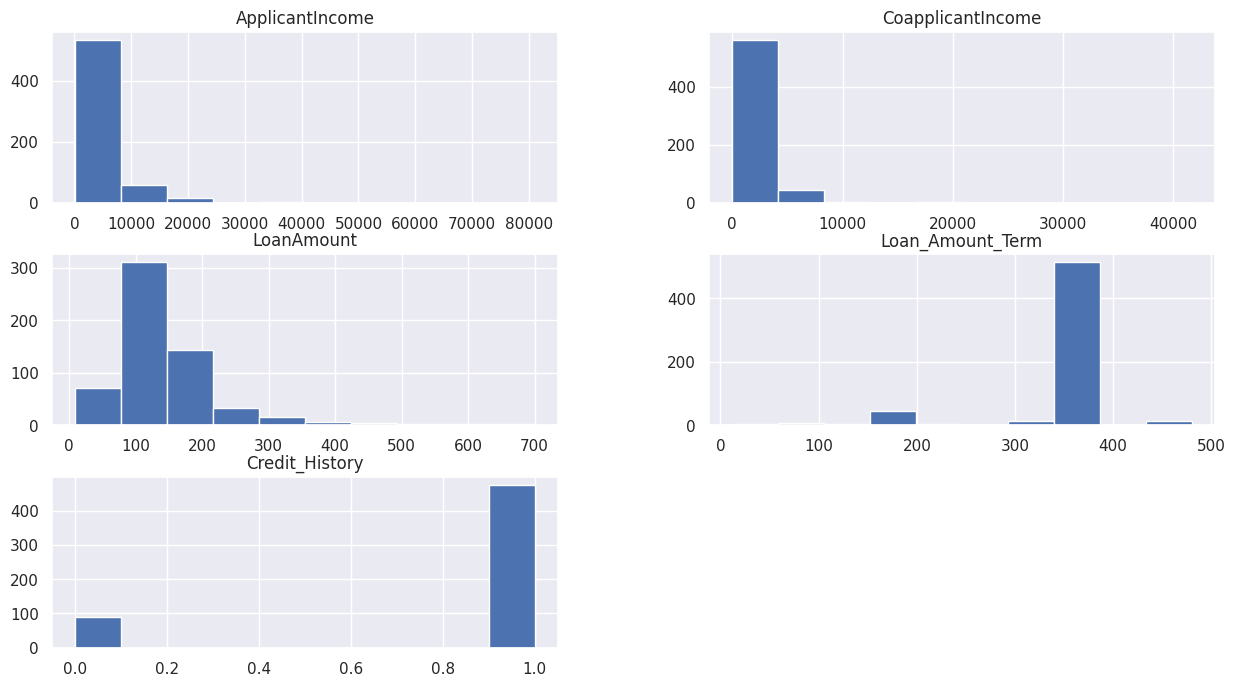

In [42]:
df.hist(figsize=(15,8))
plt.show

<Axes: xlabel='Loan_Amount_Term'>

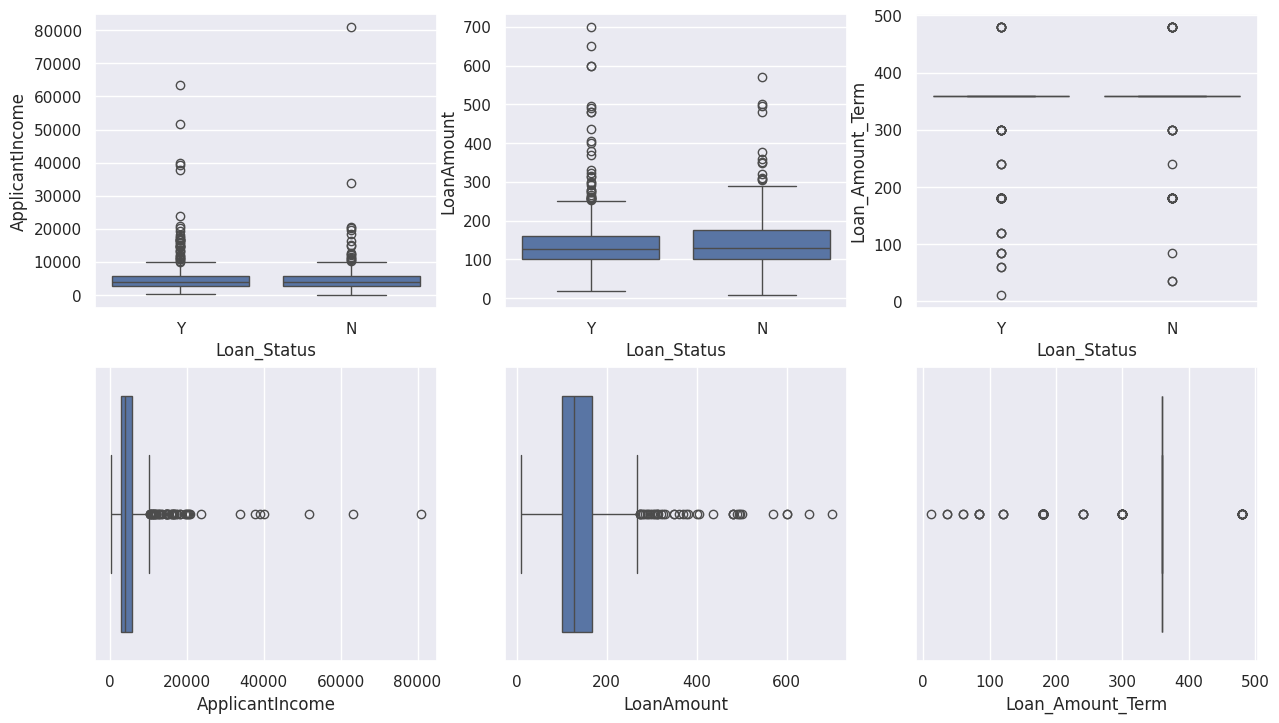

In [43]:
plt.figure(figsize=(15,13))
sns.set(font_scale = 1)
plt.subplot(331)
sns.boxplot(x=df['Loan_Status'], y=df['ApplicantIncome'])

plt.subplot(332)
sns.boxplot(x=df['Loan_Status'], y=df['LoanAmount'])

plt.subplot(333)
sns.boxplot(x=df['Loan_Status'], y=df['Loan_Amount_Term'])

plt.subplot(334)
sns.boxplot(x=df['ApplicantIncome'])

plt.subplot(335)
sns.boxplot(x=df['LoanAmount'])

plt.subplot(336)
sns.boxplot(x=df['Loan_Amount_Term'])


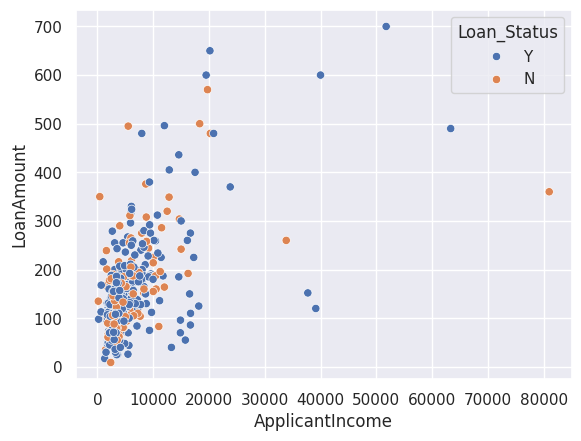

In [44]:
sns.scatterplot(
    data=df,
    x='ApplicantIncome',
    y='LoanAmount',
    hue='Loan_Status'
)

plt.show()

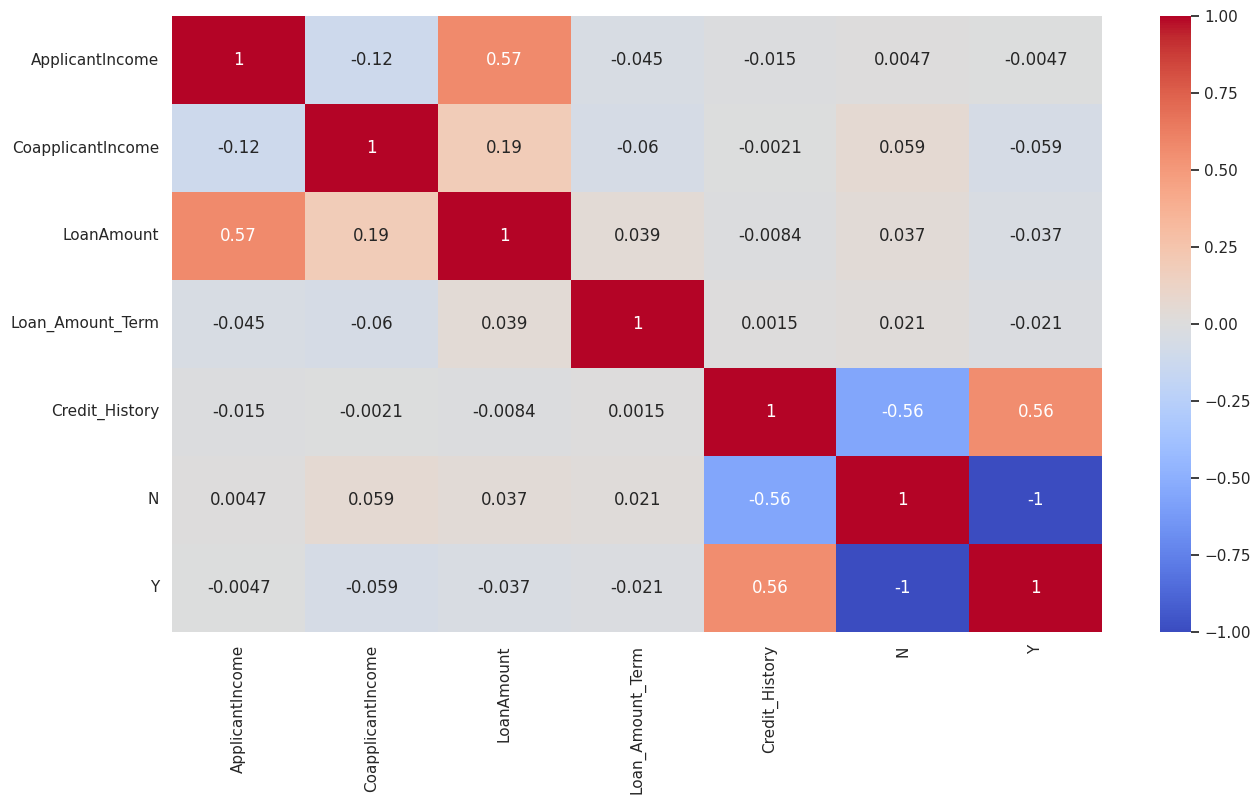

In [45]:
y_label = df['Loan_Status']
y_label = pd.get_dummies(y_label)
corr = (df.select_dtypes(include='number')).join(y_label).corr()
plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

**Split the Dataset**

In [46]:
X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)


In [47]:
X_train.shape

(491, 11)

In [48]:
X_test.shape

(123, 11)

**Data Preprocessing: Handle Missing Values and Encoding**

In [49]:
numerical_columns = X_train.select_dtypes(include="number").columns
categorical_columns = X_train.select_dtypes(include="object").columns

In [50]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scalar", StandardScaler())
])

categorical_imputer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoding", OneHotEncoder()),
])

preprocessor = ColumnTransformer([
    ("numerical_data", numeric_transformer, numerical_columns),
    ("catorigal_data", categorical_imputer, categorical_columns)
])

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)

model = Pipeline([
    ("preprocessing", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])


In [51]:
preprocessor

,transformers,"[('numerical_data', ...), ('catorigal_data', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [52]:
model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical_data', ...), ('catorigal_data', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Evaluate Model Performance**

In [53]:
y_pred = model.predict(X_test)
y_pred_test = model.predict(X_train)
y_test_encoded = label_encoder.transform(y_test)
cm = confusion_matrix(y_test_encoded, y_pred)

print(cm)

[[18 25]
 [ 4 76]]


In [54]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test_encoded))

0.8411405295315683
0.7642276422764228


In [55]:
print(f"Accuracy Test: {accuracy_score(y_test_encoded, y_pred) * 100:.2f}%")
print(f"Accuracy Train: {accuracy_score(y_train, y_pred_test) * 100:.2f}%")

Accuracy Test: 76.42%
Accuracy Train: 84.11%


In [56]:
print(f"Precision Test: {precision_score(y_test_encoded, y_pred) * 100:.2f}%")
print(f"Precision Train: {precision_score(y_train, y_pred_test) * 100:.2f}%")

Precision Test: 75.25%
Precision Train: 83.67%


In [57]:
print(f"Recall Test: {recall_score(y_test_encoded, y_pred) * 100:.2f}%")
print(f"Recall Train: {recall_score(y_train, y_pred_test) * 100:.2f}%")

Recall Test: 95.00%
Recall Train: 95.91%


In [58]:
print(f"F1-score Test: {f1_score(y_test_encoded, y_pred) * 100:.2f}%")
print(f"F1-score Train: {f1_score(y_train, y_pred_test) * 100:.2f}%")

F1-score Test: 83.98%
F1-score Train: 89.37%


In [59]:
# Training probabilities
y_train_prob = model.predict_proba(X_train)[:, 1]

# Test probabilities
y_test_prob = model.predict_proba(X_test)[:, 1]

# ROC-AUC
train_roc = roc_auc_score(y_train, y_train_prob)
test_roc = roc_auc_score(y_test_encoded, y_test_prob)

print("Training ROC-AUC:", train_roc)
print("Test ROC-AUC:", test_roc)

Training ROC-AUC: 0.9030574198359432
Test ROC-AUC: 0.6866279069767441
